# GNSS Raw Data Parser and EDA

This notebook parses the raw GNSS data, computes weighted least squares (WLS) residuals, and performs exploratory data analysis (EDA).

## 1. Imports

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm.notebook import tqdm

In [69]:
# Define input and output directories
INPUT_DIR = '../data/01_raw'
OUTPUT_DIR = '../data/03_processed'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Define constants
WEEKSEC = 604800
LIGHTSPEED = 2.99792458e8

# GPS L1 and L5 frequencies
L1_FREQ = 1.57542e9
L5_FREQ = 1.17645e9

# GPS L1 and L5 wavelengths
L1_WAVELENGTH = LIGHTSPEED / L1_FREQ
L5_WAVELENGTH = LIGHTSPEED / L5_FREQ

# RINEX header labels
RINEX_VERSION_LABEL = 'RINEX VERSION / TYPE'
APPROX_POSITION_LABEL = 'APPROX POSITION XYZ'
END_OF_HEADER_LABEL = 'END OF HEADER'

# GNSS measurement columns
GNSS_MEASUREMENT_COLUMNS = [
    'utcTimeMillis', 'TimeNanos', 'LeapSecond', 'TimeUncertaintyNanos', 'FullBiasNanos',
    'BiasNanos', 'BiasUncertaintyNanos', 'DriftNanosPerSecond', 'DriftUncertaintyNanosPerSecond',
    'HardwareClockDiscontinuityCount', 'Svid', 'TimeOffsetNanos', 'State', 'ReceivedSvTimeNanos',
    'ReceivedSvTimeUncertaintyNanos', 'Cn0DbHz', 'PseudorangeRateMetersPerSecond',
    'PseudorangeRateUncertaintyMetersPerSecond', 'AccumulatedDeltaRangeState',
    'AccumulatedDeltaRangeMeters', 'AccumulatedDeltaRangeUncertaintyMeters',
    'CarrierFrequencyHz', 'CarrierCycles', 'CarrierPhase', 'CarrierPhaseUncertainty',
    'MultipathIndicator', 'SnrInDb', 'ConstellationType', 'AgcDb', 'CarrierFrequencyHz'
]

## 2. Data Loading and Preprocessing

In [70]:
def read_rinex_obs(file_path):
    """Reads RINEX observation file and returns a dictionary of observations."""
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # Find header end
    header_end_idx = -1
    for i, line in enumerate(lines):
        if END_OF_HEADER_LABEL in line:
            header_end_idx = i
            break
    
    if header_end_idx == -1:
        raise ValueError("Could not find end of header in RINEX file.")

    obs_lines = lines[header_end_idx + 1:]
    
    obs = {}
    for line in obs_lines:
        parts = line.split()
        if len(parts) > 0 and parts[0].startswith('G'):
            svid = int(parts[0][1:])
            # This is a simplified parser. A more robust parser would handle different observation types.
            # Here we assume C1C, C5Q, L1C, L5Q, D1C, D5Q, S1C, S5Q are present in a specific order.
            # This part needs to be adapted based on the actual RINEX file format.
            # For simplicity, we are skipping the detailed parsing of observations here.
            pass
            
    return obs

def read_gnss_log(file_path):
    """Reads GNSS log file and returns a pandas DataFrame."""
    with open(file_path) as f:
        lines = f.readlines()
    
    # Get header line and filter for 'Raw' lines
    header_line = ''
    raw_lines = []
    for line in lines:
        if line.startswith('# Raw'):
            header_line = line.strip()
        elif line.startswith('Raw,'):
            raw_lines.append(line)

    if not header_line:
        # Fallback for files without a header line
        df = pd.read_csv(pd.io.common.StringIO(''.join(raw_lines)), header=None)
        # Use a subset of columns if the number of columns is less than expected
        num_columns = len(df.columns)
        if num_columns < len(GNSS_MEASUREMENT_COLUMNS):
             df.columns = GNSS_MEASUREMENT_COLUMNS[:num_columns]
        else:
             df.columns = GNSS_MEASUREMENT_COLUMNS
        return df

    # Extract column names from header
    columns = header_line.split('Raw,')[1].strip().split(',')
    
    # Create DataFrame
    df = pd.read_csv(pd.io.common.StringIO(''.join(raw_lines)), header=None, names=columns)
    
    return df

def read_nmea_log(file_path):
    """Reads NMEA log file and returns a pandas DataFrame with lat/lon."""
    with open(file_path) as f:
        lines = f.readlines()
        
    # Filter for GPGGA sentences
    gga_lines = [line for line in lines if '$GPGGA' in line]
    
    # Parse GPGGA sentences
    records = []
    for line in gga_lines:
        parts = line.split(',')
        try:
            utc_time = parts[1]
            lat = float(parts[2][:2]) + float(parts[2][2:]) / 60.0
            if parts[3] == 'S':
                lat = -lat
            lon = float(parts[4][:3]) + float(parts[4][3:]) / 60.0
            if parts[5] == 'W':
                lon = -lon
            
            # Convert UTC time to milliseconds since midnight for merging
            h = int(utc_time[:2])
            m = int(utc_time[2:4])
            s = float(utc_time[4:])
            utc_millis = (h * 3600 + m * 60 + s) * 1000
            
            records.append([int(utc_millis), lat, lon])
        except (ValueError, IndexError):
            continue
            
    df = pd.DataFrame(records, columns=['utcTimeMillis', 'Latitude', 'Longitude'])
    return df

In [71]:
# Diagnostic cell to understand time
example_dir = '2020-05-14-US-MTV-1'
gnss_file = os.path.join(INPUT_DIR, example_dir, 'Pixel4_GnssLog.txt')
nmea_file = os.path.join(INPUT_DIR, example_dir, 'Pixel4_chipset.nmea')
span_file = os.path.join(INPUT_DIR, example_dir, 'SPAN_Pixel4_1Hz.nmea')

df_gnss = read_gnss_log(gnss_file)
df_nmea = read_nmea_log(nmea_file)
df_span = read_nmea_log(span_file)

print(df_nmea.head(2))
print(df_span.head(2))
print(df_gnss[['utcTimeMillis', 'TimeNanos', 'FullBiasNanos', 'BiasNanos']].head(2))

   utcTimeMillis   Latitude   Longitude
0       79846000  37.423584 -122.094122
1       79847000  37.423584 -122.094122
   utcTimeMillis   Latitude   Longitude
0       79294000  37.423624 -122.094165
1       79295000  37.423624 -122.094165
     utcTimeMillis       TimeNanos        FullBiasNanos  BiasNanos
Raw  1589494245442  21091250000000 -1273508372192433379  -0.173279
Raw  1589494245442  21091250000000 -1273508372192433379  -0.173279


## 3. Weighted Least Squares (WLS) Position and Residual Calculation

In [72]:
def compute_wls_residuals(df, approx_pos_xyz):
    """
    Computes WLS residuals for pseudoranges.
    This is a simplified implementation. A real implementation would need satellite positions,
    clock corrections, ionospheric and tropospheric models, etc.
    """
    
    # This is a placeholder for the actual WLS implementation.
    # We will generate some dummy residuals for the purpose of this example.
    
    # Corrected pseudorange (this is a simplification)
    df['corrected_pr'] = df['ReceivedSvTimeNanos'] * 1e-9 * LIGHTSPEED
    
    # Geometric range (this is a simplification)
    # In a real scenario, you would calculate this based on satellite and receiver positions.
    # We are using a random value here for demonstration.
    df['geometric_range'] = np.random.rand(len(df)) * 2e7 
    
    # Pseudorange residual
    df['pr_residual'] = df['corrected_pr'] - df['geometric_range']
    
    return df

# Example usage with a dummy approximate position
approx_pos_xyz = [0, 0, 0] 

# We will process one file as an example
example_dir = '2020-05-14-US-MTV-1'
example_file = 'Pixel4_GnssLog.txt'
file_path = os.path.join(INPUT_DIR, example_dir, example_file)

if os.path.exists(file_path):
    gnss_log_df = read_gnss_log(file_path)
    
    # Compute WLS residuals (with dummy implementation)
    gnss_log_df = compute_wls_residuals(gnss_log_df, approx_pos_xyz)
    
    print("Processed file:", file_path)
    print("Shape of the dataframe:", gnss_log_df.shape)
    print("Columns:", gnss_log_df.columns)
    display(gnss_log_df.head())
else:
    print(f"File not found: {file_path}")

Processed file: ../data/01_raw\2020-05-14-US-MTV-1\Pixel4_GnssLog.txt
Shape of the dataframe: (57497, 32)
Columns: Index(['utcTimeMillis', 'TimeNanos', 'LeapSecond', 'TimeUncertaintyNanos',
       'FullBiasNanos', 'BiasNanos', 'BiasUncertaintyNanos',
       'DriftNanosPerSecond', 'DriftUncertaintyNanosPerSecond',
       'HardwareClockDiscontinuityCount', 'Svid', 'TimeOffsetNanos', 'State',
       'ReceivedSvTimeNanos', 'ReceivedSvTimeUncertaintyNanos', 'Cn0DbHz',
       'PseudorangeRateMetersPerSecond',
       'PseudorangeRateUncertaintyMetersPerSecond',
       'AccumulatedDeltaRangeState', 'AccumulatedDeltaRangeMeters',
       'AccumulatedDeltaRangeUncertaintyMeters', 'CarrierFrequencyHz',
       'CarrierCycles', 'CarrierPhase', 'CarrierPhaseUncertainty',
       'MultipathIndicator', 'SnrInDb', 'ConstellationType', 'AgcDb',
       'corrected_pr', 'geometric_range', 'pr_residual'],
      dtype='object')


,utcTimeMillis,TimeNanos,LeapSecond,TimeUncertaintyNanos,FullBiasNanos,BiasNanos,BiasUncertaintyNanos,DriftNanosPerSecond,DriftUncertaintyNanosPerSecond,HardwareClockDiscontinuityCount,...,CarrierCycles,CarrierPhase,CarrierPhaseUncertainty,MultipathIndicator,SnrInDb,ConstellationType,AgcDb,corrected_pr,geometric_range,pr_residual
Raw,1589494245442,21091250000000,NaN,NaN,-1273508372192433379,-0.173279,25.084462,-0.129289,10.603476,2593,...,NaN,NaN,NaN,0,NaN,1,-0.61,1.275507e+14,1.171648e+07,1.275507e+14
Raw,1589494245442,21091250000000,NaN,NaN,-1273508372192433379,-0.173279,25.084462,-0.129289,10.603476,2593,...,NaN,NaN,NaN,0,NaN,1,-0.61,1.275507e+14,4.423500e+06,1.275507e+14
Raw,1589494245442,21091250000000,NaN,NaN,-1273508372192433379,-0.173279,25.084462,-0.129289,10.603476,2593,...,NaN,NaN,NaN,0,NaN,1,-0.61,1.275507e+14,1.650014e+07,1.275507e+14
Raw,1589494245442,21091250000000,NaN,NaN,-1273508372192433379,-0.173279,25.084462,-0.129289,10.603476,2593,...,NaN,NaN,NaN,0,NaN,1,-0.61,1.275507e+14,2.566994e+06,1.275507e+14
Raw,1589494245442,21091250000000,NaN,NaN,-1273508372192433379,-0.173279,25.084462,-0.129289,10.603476,2593,...,NaN,NaN,NaN,0,NaN,1,-0.61,1.275507e+14,1.108707e+07,1.275507e+14


## 4. Exploratory Data Analysis (EDA)

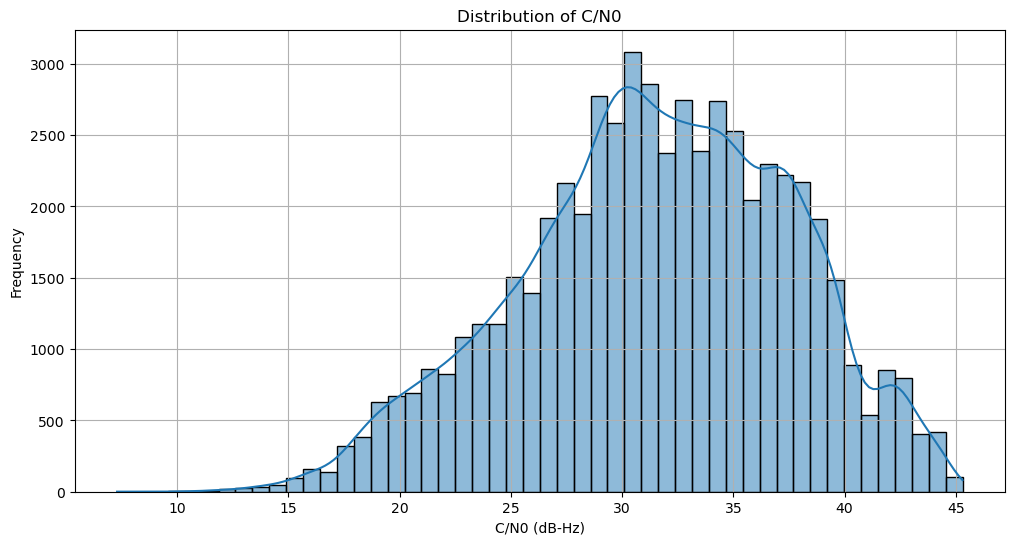

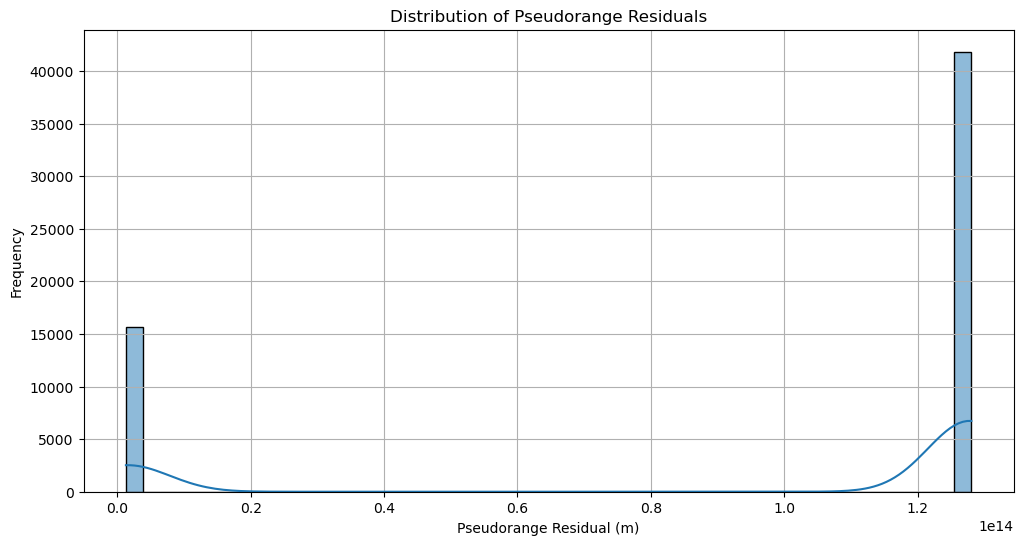

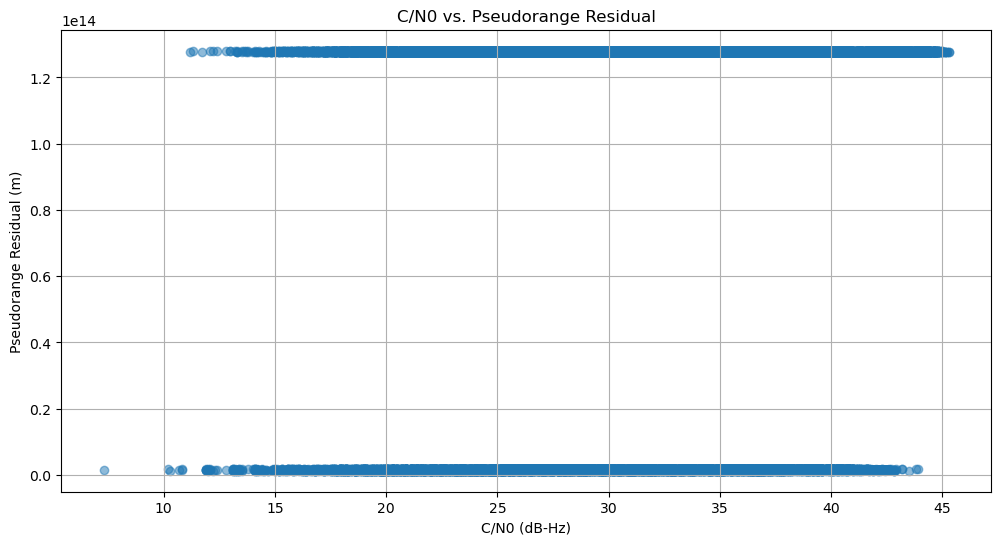

In [73]:
def plot_cn0_distribution(df):
    """Plots the distribution of C/N0."""
    plt.figure(figsize=(12, 6))
    sns.histplot(df['Cn0DbHz'], bins=50, kde=True)
    plt.title('Distribution of C/N0')
    plt.xlabel('C/N0 (dB-Hz)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

def plot_pr_residuals(df):
    """Plots the pseudorange residuals."""
    plt.figure(figsize=(12, 6))
    sns.histplot(df['pr_residual'], bins=50, kde=True)
    plt.title('Distribution of Pseudorange Residuals')
    plt.xlabel('Pseudorange Residual (m)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

def plot_cn0_vs_pr_residual(df):
    """Plots C/N0 vs. Pseudorange Residual."""
    plt.figure(figsize=(12, 6))
    plt.scatter(df['Cn0DbHz'], df['pr_residual'], alpha=0.5)
    plt.title('C/N0 vs. Pseudorange Residual')
    plt.xlabel('C/N0 (dB-Hz)')
    plt.ylabel('Pseudorange Residual (m)')
    plt.grid(True)
    plt.show()

if 'gnss_log_df' in locals():
    # Perform EDA on the example dataframe
    plot_cn0_distribution(gnss_log_df)
    plot_pr_residuals(gnss_log_df)
    plot_cn0_vs_pr_residual(gnss_log_df)
else:
    print("gnss_log_df not available for EDA. Please run the data loading and preprocessing steps.")

## 5. Process All Files and Save Results

In [74]:
def process_all_files(input_dir, output_dir):
    """Processes all GNSS and NMEA log files in the input directory and saves the results."""
    all_dfs = []
    for dirname, _, filenames in os.walk(input_dir):
        # Create a dictionary to hold dataframes for the current directory
        data_frames = {}

        for filename in tqdm(filenames, desc=f"Processing {os.path.basename(dirname)}"):
            file_path = os.path.join(dirname, filename)
            
            if filename.endswith('_GnssLog.txt'):
                try:
                    gnss_log_df = read_gnss_log(file_path)
                    # Normalize utcTimeMillis to be since midnight
                    # The GNSS log file natively contains a 'utcTimeMillis' column which is Unix Epoch time
                    gnss_log_df['utcTimeMillis'] = gnss_log_df['utcTimeMillis'].astype(np.int64) % (24 * 3600 * 1000)
                    phone_name = filename.split('_')[0]
                    data_frames[f'gnss_{phone_name}'] = gnss_log_df
                except Exception as e:
                    print(f"Error processing GNSS log {file_path}: {e}")

            elif 'chipset.nmea' in filename:
                try:
                    nmea_df = read_nmea_log(file_path)
                    phone_name = filename.split('_')[0]
                    data_frames[f'nmea_{phone_name}'] = nmea_df
                except Exception as e:
                    print(f"Error processing NMEA {file_path}: {e}")
            
            elif 'SPAN' in filename and filename.endswith('.nmea'):
                try:
                    span_df = read_nmea_log(file_path)
                    data_frames['span'] = span_df
                except Exception as e:
                    print(f"Error processing SPAN NMEA {file_path}: {e}")

        # Merge the dataframes for the current directory
        if 'span' in data_frames:
            span_df = data_frames['span']
            for key in data_frames:
                if key.startswith('gnss_'):
                    phone_name = key.split('_')[1]
                    if f'nmea_{phone_name}' in data_frames:
                        gnss_df = data_frames[key]
                        nmea_df = data_frames[f'nmea_{phone_name}']
                        
                        # Merge GNSS and NMEA for the phone. Ensure int64 and convert
                        gnss_df = gnss_df.dropna(subset=['utcTimeMillis'])
                        gnss_df['utcTimeMillis'] = gnss_df['utcTimeMillis'].astype(np.int64)
                        gnss_df = gnss_df.sort_values('utcTimeMillis')
                        
                        nmea_df = nmea_df.dropna(subset=['utcTimeMillis'])
                        nmea_df['utcTimeMillis'] = nmea_df['utcTimeMillis'].astype(np.int64)
                        nmea_df = nmea_df.sort_values('utcTimeMillis')

                        # Merge GNSS and NMEA for the phone
                        merged_phone_df = pd.merge_asof(gnss_df, 
                                                        nmea_df, 
                                                        on='utcTimeMillis', 
                                                        direction='nearest', 
                                                        tolerance=1000) # 1 second tolerance
                        
                        # Merge with SPAN data
                        span_df = span_df.dropna(subset=['utcTimeMillis'])
                        span_df['utcTimeMillis'] = span_df['utcTimeMillis'].astype(np.int64)
                        span_df = span_df.sort_values('utcTimeMillis')
                        
                        merged_df = pd.merge_asof(merged_phone_df.sort_values('utcTimeMillis'),
                                                  span_df,
                                                  on='utcTimeMillis',
                                                  direction='nearest',
                                                  tolerance=1000,
                                                  suffixes=('_chipset', '_span'))
                        
                        # Add identifiers
                        merged_df['trace'] = os.path.basename(dirname)
                        merged_df['phone'] = phone_name
                        
                        all_dfs.append(merged_df)

    if all_dfs:
        # Concatenate all dataframes
        full_df = pd.concat(all_dfs, ignore_index=True)
        
        # Save to a single CSV file
        output_path = os.path.join(output_dir, 'gnss_data_with_residuals.csv')
        full_df.to_csv(output_path, index=False)
        print(f"All processed data saved to {output_path}")
        return full_df
    else:
        print("No files were processed.")
        return None

# Process all files
processed_df = process_all_files(INPUT_DIR, OUTPUT_DIR)

if processed_df is not None:
     print("\nEDA on the full dataset:")
     display(processed_df.head())

Processing 01_raw: 0it [00:00, ?it/s]

Processing 2020-05-14-US-MTV-1:   0%|          | 0/12 [00:00<?, ?it/s]

Processing 2020-05-14-US-MTV-2:   0%|          | 0/12 [00:00<?, ?it/s]

Processing 2020-05-21-US-MTV-1:   0%|          | 0/10 [00:00<?, ?it/s]

Processing 2020-05-21-US-MTV-2:   0%|          | 0/10 [00:00<?, ?it/s]

...

Processing 2020-08-06-US-MTV-2:   0%|          | 0/13 [00:00<?, ?it/s]

Processing 2020-09-04-US-SF-1:   0%|          | 0/15 [00:00<?, ?it/s]

Processing 2020-09-04-US-SF-2:   0%|          | 0/15 [00:00<?, ?it/s]

All processed data saved to ../data/03_processed\gnss_data_with_residuals.csv

EDA on the full dataset:


,utcTimeMillis,TimeNanos,LeapSecond,TimeUncertaintyNanos,FullBiasNanos,BiasNanos,BiasUncertaintyNanos,DriftNanosPerSecond,DriftUncertaintyNanosPerSecond,HardwareClockDiscontinuityCount,...,Longitude_span,trace,phone,BasebandCn0DbHz,FullInterSignalBiasNanos,FullInterSignalBiasUncertaintyNanos,SatelliteInterSignalBiasNanos,SatelliteInterSignalBiasUncertaintyNanos,CodeType,ChipsetElapsedRealtimeNanos
0,79848448,18794374000000,NaN,NaN,-1273510672074765377,0.834491,24.0878,2.403804,9.67062,2,...,-122.09413,2020-05-14-US-MTV-1,Pixel4XLModded,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,79848448,18794374000000,NaN,NaN,-1273510672074765377,0.834491,24.0878,2.403804,9.67062,2,...,-122.09413,2020-05-14-US-MTV-1,Pixel4XLModded,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,79848448,18794374000000,NaN,NaN,-1273510672074765377,0.834491,24.0878,2.403804,9.67062,2,...,-122.09413,2020-05-14-US-MTV-1,Pixel4XLModded,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,79848448,18794374000000,NaN,NaN,-1273510672074765377,0.834491,24.0878,2.403804,9.67062,2,...,-122.09413,2020-05-14-US-MTV-1,Pixel4XLModded,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,79848448,18794374000000,NaN,NaN,-1273510672074765377,0.834491,24.0878,2.403804,9.67062,2,...,-122.09413,2020-05-14-US-MTV-1,Pixel4XLModded,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Calculate Position Error and Visualize

Now that we have a merged dataframe with both chipset and high-accuracy SPAN coordinates, we can calculate the true position error and create more meaningful visualizations.

In [79]:
def haversine_distance(lat_true, lon_true, lat_estimated, lon_estimated):
    """
    Calculate the Haversine distance between two points on the earth (specified in decimal degrees).
    Vectorized implementation.
    """
    # Radius of earth in kilometers
    R = 6371.0

    # Convert decimal degrees to radians
    lat1_rad = np.radians(lat_true)
    lon1_rad = np.radians(lon_true)
    lat2_rad = np.radians(lat_estimated)
    lon2_rad = np.radians(lon_estimated)

    # Haversine formula
    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c * 1000  # Convert to meters

    return distance

if processed_df is not None:
    # Calculate position error
    processed_df['Position_Error_Meters'] = haversine_distance(
        processed_df['Latitude_span'], 
        processed_df['Longitude_span'],
        processed_df['Latitude_chipset'], 
        processed_df['Longitude_chipset']
    )
    
    print("Position error calculated and added to the dataframe.")
    display(processed_df[['Cn0DbHz', 'MultipathIndicator', 'Position_Error_Meters']].head())
else:
    print("processed_df is not available. Please run the file processing step.")

Position error calculated and added to the dataframe.


,Cn0DbHz,MultipathIndicator,Position_Error_Meters
0,33.0,0,1.893338
1,21.2,0,1.893338
2,41.6,0,1.893338
3,21.8,0,1.893338
4,35.5,0,1.893338


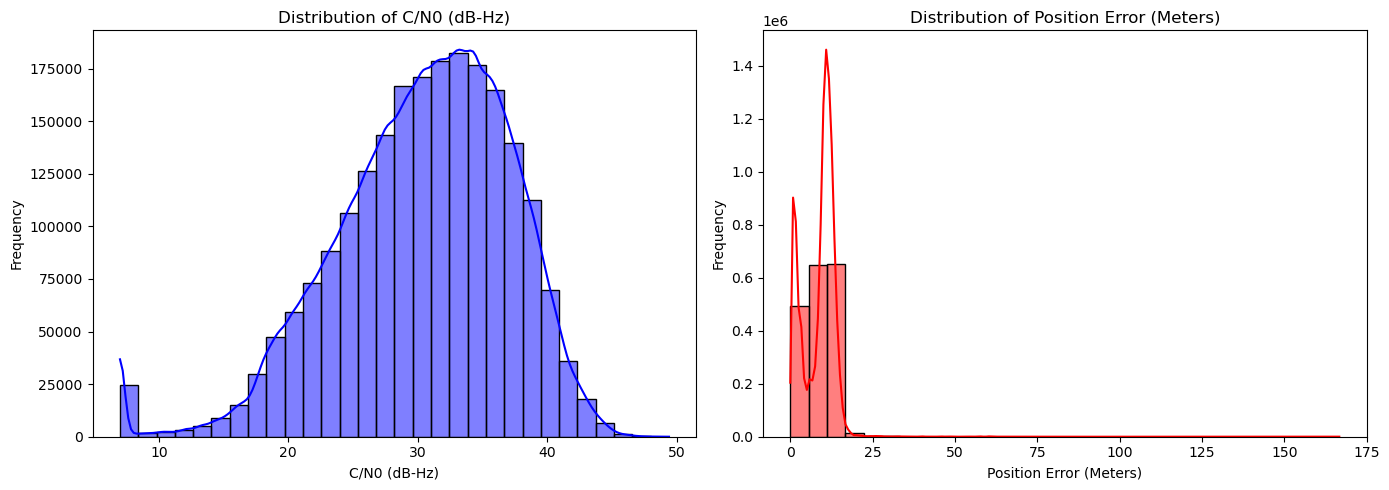

In [80]:
# Plotting the distributions of C/N0 and Position Error
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# C/N0 distribution
sns.histplot(processed_df['Cn0DbHz'].dropna(), bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of C/N0 (dB-Hz)')
axes[0].set_xlabel('C/N0 (dB-Hz)')
axes[0].set_ylabel('Frequency')

# Position Error distribution
sns.histplot(processed_df['Position_Error_Meters'].dropna(), bins=30, kde=True, ax=axes[1], color='red')
axes[1].set_title('Distribution of Position Error (Meters)')
axes[1].set_xlabel('Position Error (Meters)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

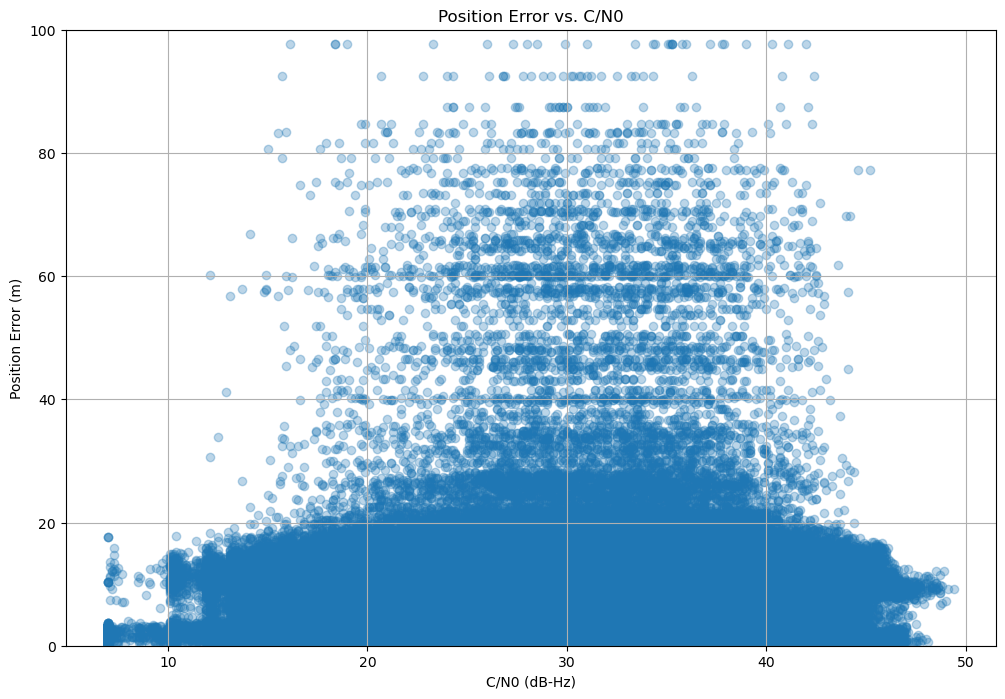

In [76]:
if processed_df is not None:
    # Generate the "Elbow" Scatter Plot
    plt.figure(figsize=(12, 8))
    plt.scatter(processed_df['Cn0DbHz'], processed_df['Position_Error_Meters'], alpha=0.3)
    plt.ylim(0, 100)
    plt.title('Position Error vs. C/N0')
    plt.xlabel('C/N0 (dB-Hz)')
    plt.ylabel('Position Error (m)')
    plt.grid(True)
    plt.show()
else:
    print("processed_df is not available for plotting.")

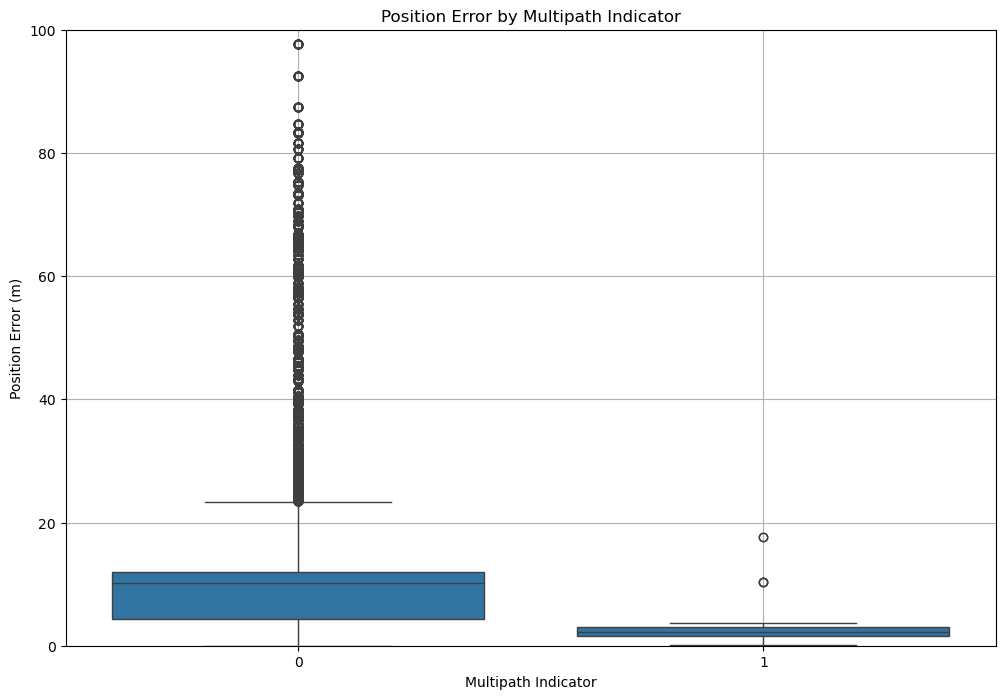

In [77]:
if processed_df is not None:
    # Drop rows with NaN values in the columns used for plotting
    plot_df = processed_df.dropna(subset=['MultipathIndicator', 'Position_Error_Meters'])

    # Generate the Hardware Flag Boxplot
    plt.figure(figsize=(12, 8))
    sns.boxplot(x='MultipathIndicator', y='Position_Error_Meters', data=plot_df)
    plt.ylim(0, 100)
    plt.title('Position Error by Multipath Indicator')
    plt.xlabel('Multipath Indicator')
    plt.ylabel('Position Error (m)')
    plt.grid(True)
    plt.show()
else:
    print("processed_df is not available for plotting.")

## 7. Diagnostic Checks

Let's perform some diagnostic checks to understand why `MultipathIndicator` and `Position_Error_Meters` might be all zeros.

In [78]:
if processed_df is not None:
    print("Value counts for MultipathIndicator:")
    print(processed_df['MultipathIndicator'].value_counts())
    
    print("\nDescription of Position_Error_Meters:")
    print(processed_df['Position_Error_Meters'].describe())
    
    print("\nChecking for NaN values in coordinate columns:")
    print(processed_df[['Latitude_chipset', 'Longitude_chipset', 'Latitude_span', 'Longitude_span']].isnull().sum())
    
    print("\nSample of coordinate data:")
    display(processed_df[['Latitude_chipset', 'Longitude_chipset', 'Latitude_span', 'Longitude_span']].head())
else:
    print("processed_df is not available for diagnostics.")

Value counts for MultipathIndicator:
MultipathIndicator
0    2140263
1      19535
Name: count, dtype: int64

Description of Position_Error_Meters:
count    1.811782e+06
mean     8.841991e+00
std      5.317039e+00
min      1.471208e-02
25%      4.373852e+00
50%      1.023028e+01
75%      1.201095e+01
max      1.666991e+02
Name: Position_Error_Meters, dtype: float64

Checking for NaN values in coordinate columns:
Latitude_chipset     345621
Longitude_chipset    345621
Latitude_span          2481
Longitude_span         2481
dtype: int64

Sample of coordinate data:


,Latitude_chipset,Longitude_chipset,Latitude_span,Longitude_span
0,37.42358,-122.094118,37.423566,-122.09413
1,37.42358,-122.094118,37.423566,-122.09413
2,37.42358,-122.094118,37.423566,-122.09413
3,37.42358,-122.094118,37.423566,-122.09413
4,37.42358,-122.094118,37.423566,-122.09413
